# Learning jaxrts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jaxrts/jaxrts/blob/main/notebooks/00-jaxrts_intro.ipynb)

## Setting up everything

this will install the newest version of jaxrts, do all required imports, and then you should be good to go.

In [1]:
# lets get the latest version of jaxrts
!pip install git+https://github.com/jaxrts/jaxrts

  Cloning https://github.com/jaxrts/jaxrts to /tmp/pip-req-build-yd_snory
  Running command git clone --filter=blob:none --quiet https://github.com/jaxrts/jaxrts /tmp/pip-req-build-yd_snory
  Resolved https://github.com/jaxrts/jaxrts to commit 1210e9d96900f0209032b4c0d93dbc62926577a0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/jluetgert/jpu/ to /tmp/pip-install-dr633wg3/jpu_aa3bd27c30bf4f2f819e038b2bb2f52b
  Running command git clone --filter=blob:none --quiet https://github.com/jluetgert/jpu/ /tmp/pip-install-dr633wg3/jpu_aa3bd27c30bf4f2f819e038b2bb2f52b
  Resolved https://github.com/jluetgert/jpu/ to commit dd3513f85a10f4324d3e0ccf99801f00089e2459
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://codeberg.org/pybtex/pybtex/ to /tmp/pip-install-dr633wg3/pybtex_557be

In [2]:
from functools import partial

import matplotlib.pyplot as plt

# jax provides a submodule which can be (mostly) used as a drop-in replacement
# for numpy. We use jnp to avoid confusion.
from jax import numpy as jnp

import jaxrts

# We use the jpu package (which is enabling the usage of pint with jax) to
# handle units. See below for how to use this
ureg = jaxrts.ureg

## Define your PlasmaState and Setup

In [3]:
setup = jaxrts.Setup(
    scattering_angle=ureg("45 degree"),
    energy=ureg("4700 eV"),
    measured_energy=jnp.linspace(4600, 4740, 500) * ureg.electron_volt,
    instrument=jaxrts.instrument_function.Gaussian(fwhm= 5 * ureg.electron_volt)
)

In [4]:
# Initialize a Plasma State (We use a Berillium Plasma, here)
state = jaxrts.PlasmaState(
    ions=[jaxrts.Element("Be")],  # Specify the elements as a list
    Z_free=jnp.array([2.9]),  # This is the ionization per species
    mass_density=jnp.array([3]) * ureg.gram / ureg.centimeter**3,
    T_e=10 * ureg.electron_volt / ureg.k_B,  # T_e is the electron temperature.
    # If no T_i (ion temperature) is given, we assume equilibrium of ion and
    # electron temperatures
)

# Add Models

state["ion-ion Potential"] = jaxrts.hnc_potentials.DebyeHueckelPotential()
state["electron-ion Potential"] = jaxrts.hnc_potentials.CoulombPotential()
state["screening"] = jaxrts.models.FiniteWavelengthScreening()
state["ipd"] = jaxrts.models.StewartPyattIPD()
state["ionic scattering"] = jaxrts.models.OnePotentialHNCIonFeat()
state["free-free scattering"] = jaxrts.models.RPA_DandreaFit()
state["bound-free scattering"] = jaxrts.models.SchumacherImpulse()
state["free-bound scattering"] = jaxrts.models.DetailedBalance()
state["screening length"] = jaxrts.models.ArbitraryDegeneracyScreeningLength()

# Expand fractional ionization states to integers
state = state.expand_integer_ionization_states()

Setting default 'form-factors' model to 'PaulingFormFactors'. You can suppress this warning by setting the model manually.
Setting default 'bf edge' model to 'Heaviside'. You can suppress this warning by setting the model manually.


## Probe

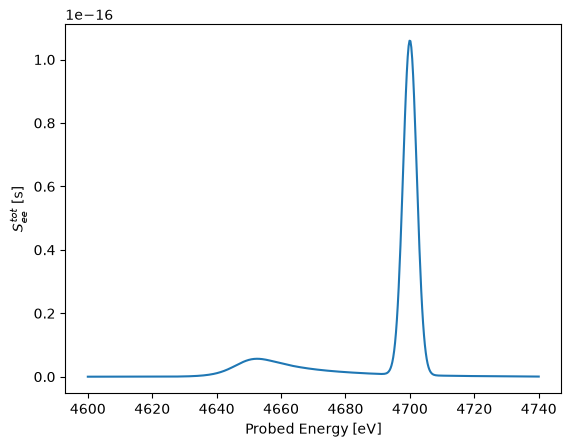

ions                     :      Be,      Be
mass densities (g/cc)    :    0.30,    2.70
ionization               :    2.00,    3.00
ion temperatures (eV)    :    10.0,    10.0
e- temperature (eV)      :    10.0

Models attached
screening length         : ArbitraryDegeneracyScreeningLength
ee-lfc                   : LFCConstant
free-bound scattering    : DetailedBalance
ion-ion Potential        : DebyeHueckelPotential
electron-ion Potential   : CoulombPotential
screening                : FiniteWavelengthScreening
ipd                      : StewartPyatt
form-factors             : PaulingFormFactors
ionic scattering         : OnePotentialHNCIonFeat
free-free scattering     : RPA_DandreaFit
bf edge                  : Heaviside
bound-free scattering    : SchumacherImpulse
        

Setup probing with 4700.0 eV at 45.000000 deg (k = 1.823/angstrom).


In [5]:
See_tot = state.probe(setup)

# Plot the result
fig, ax = plt.subplots()
ax.plot(
    setup.measured_energy.m_as(ureg.electron_volt),
    See_tot.m_as(ureg.second),
)
ax.set_xlabel("Probed Energy [eV]")
ax.set_ylabel("$S_{ee}^{tot}$ [s]")
plt.show()
print(state)
print()
print(setup)

## Showing available models

This list gives you an overview over all models that are available in jaxrts.

In [6]:
available_models = jaxrts.get_all_models(names_only=True)
print("Available model keys:\n")
print("\n".join(f"- {k}" for k in available_models.keys()))

Available model keys:

- screening length
- ionic scattering
- BM S_ii
- Debye temperature
- free-free scattering
- chemical potential
- ipd
- screening
- BM V_eiS
- free-bound scattering
- ee-lfc
- bf edge
- form-factors
- bound-free scattering
- ion-ion Potential
- electron-ion Potential
- electron-electron Potential


In [7]:
key = "ionic scattering"
print(f"Available models for key {key}:\n")
print("\n".join(f"- {m}" for m in available_models[key]))

Available models for key ionic scattering:

- ArkhipovIonFeat
- CHSIonFeat
- DebyeWallerSolid
- FixedSii
- Gregori2003IonFeat
- Gregori2006IonFeat
- Neglect
- OnePotentialHNCIonFeat
- PeakCollection
- ThreePotentialHNCIonFeat
